# **Mini-project 6.3 Customer segmentation with clustering**

This mini-project applies unsupervised machine learning techniques to perform customer segmentation on a real-world e-commerce dataset provided by SAS (2024), containing 951,669 transactions from 47 countries across five continents. The dataset spans orders between January 2012 and December 2016, with each row representing a product ordered by a customer. The aim is to identify distinct customer groups based on five engineered behavioural and demographic features — Frequency, Recency, Customer Lifetime Value (CLV), Average Unit Cost, and Age — using clustering algorithms including K-means and Hierarchical clustering. The resulting segments will enable the business to develop targeted marketing strategies, improve customer retention, and allocate resources more effectively.

---
# 1. Data Import

In [ ]:
# Import data manipulation libraries
import pandas as pd
import numpy as np

# Import visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import preprocessing and dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Import clustering algorithms and metrics
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('https://github.com/FourthRevGitHub/CAM_DS_Public-Data-Sets/raw/main/Course%201/Week%206/CUSTOMERS_CLEAN.zip')

---
# 2. Exploratory Data Analysis (EDA)

In [ ]:
# Check dataset dimensions and preview first 5 rows
print(data.shape)
data.head()

(951669, 20)


,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,$28.50,$9.10,.,Internet Sale,Australia,08MAY1978,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,$1.20,6,99,8818
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$113.40,$56.90,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,($0.40),3,99,47793
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$41.00,$18.50,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,$4.00,3,99,47793
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,$35.20,$29.60,.,Internet Sale,Australia,22JUN1997,Orion Club Gold members,Orion Club Gold members high activity,1230000268,$5.60,2,0,71727
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,$24.70,$23.60,.,Internet Sale,Canada,28JAN1978,Orion Club Gold members,Orion Club Gold members medium activity,1230000487,$1.10,3,99,74503


In [ ]:
# Check data types and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951669 entries, 0 to 951668
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Quantity              951669 non-null  int64 
 1   City                  951534 non-null  object
 2   Continent             951669 non-null  object
 3   Postal_Code           947953 non-null  object
 4   State_Province        834477 non-null  object
 5   Order_Date            951669 non-null  object
 6   Delivery_Date         951669 non-null  object
 7   Total Revenue         951669 non-null  object
 8   Unit Cost             951669 non-null  object
 9   Discount              951669 non-null  object
 10  OrderTypeLabel        951669 non-null  object
 11  CustomerCountryLabel  951669 non-null  object
 12  Customer_BirthDate    951669 non-null  object
 13  Customer_Group        951669 non-null  object
 14  Customer_Type         951669 non-null  object
 15  Order ID         

In [ ]:
# Count missing values per column
data.isnull().sum()

,0
Quantity,0
City,135
Continent,0
Postal_Code,3716
State_Province,117192
Order_Date,0
Delivery_Date,0
Total Revenue,0
Unit Cost,0
Discount,0


The dataset contains 951,669 rows and 20 columns with missing values in three columns: City (135), Postal_Code (3,716), and State_Province (117,192). However, as the analysis requires only five engineered features — Frequency, Recency, CLV, Average Unit Cost, and Customer Age — none of which depend on these columns, the missing values do not impact the scope of this project and no imputation is required.

In [ ]:
# Count duplicate rows
data.duplicated().sum()

np.int64(21)

In [ ]:
# Remove duplicates, keeping first occurrence
data.drop_duplicates(keep='first', inplace=True)
print(data.shape)

(951648, 20)


The dataset contained 21 duplicate rows, representing less than 0.003% of the total observations. As duplicates likely reflect data entry errors rather than genuine transactions, they were removed, retaining the first occurrence of each duplicated record.

In [ ]:
# Convert date columns from string to datetime format
data['Order_Date'] = pd.to_datetime(data['Order_Date'], format='%d%b%Y')
data['Delivery_Date'] = pd.to_datetime(data['Delivery_Date'], format = '%d%b%Y')
data['Customer_BirthDate'] = pd.to_datetime(data['Customer_BirthDate'], format = '%d%b%Y')
data[['Order_Date', 'Delivery_Date', 'Customer_BirthDate']].dtypes

,0
Order_Date,datetime64[ns]
Delivery_Date,datetime64[ns]
Customer_BirthDate,datetime64[ns]


Three columns — Order_Date, Delivery_Date, and Customer_BirthDate — were stored as string objects rather than datetime format. These were converted to datetime64 using pd.to_datetime() with the format '%d%b%Y' (e.g. 01JAN2012) to enable date arithmetic required for feature engineering.

In [ ]:
# Define a custom function to convert currency strings to float
def currency_to_float(value):
    value = str(value)
    value = value.replace('$', '')
    value = value.replace(',', '')
    value = value.strip()
    if '(' in value:
        value = value.replace('(', '')
        value = value.replace(')', '')
        value = '-' + value
    return float(value)

# Apply to currency columns
data['Total Revenue'] = data['Total Revenue'].apply(currency_to_float)
data['Unit Cost'] = data['Unit Cost'].apply(currency_to_float)

data[['Total Revenue', 'Unit Cost']].dtypes

,0
Total Revenue,float64
Unit Cost,float64


The Total Revenue and Unit Cost columns were stored as string objects containing currency symbols ($), thousands separators (,), and in some cases parentheses indicating negative values (e.g. (0.40)).

A custom currency_to_float() function was applied to strip these characters and convert both columns to float64 format, enabling numerical computation for feature engineering.

---
# 3. Feature Engineering & Scaling

## 3.1 Creating new features

In [ ]:
# Aggregate from order-level to customer-level (one row per customer)
# Frequency = count of orders, CLV = total revenue, Avg_Unit_Cost = mean unit cost
# Recency = most recent order date, DOB = birthdate (for age calculation)
df_aggr = data.groupby('Customer ID').agg(
    Frequency=('Order ID', 'count'),
    CLV=('Total Revenue', 'sum'),
    Avg_Unit_Cost=('Unit Cost', 'mean'),
    Recency=('Order_Date', 'max'),
    DOB=('Customer_BirthDate', 'first')
).reset_index()

df_aggr.head()

,Customer ID,Frequency,CLV,Avg_Unit_Cost,Recency,DOB
0,1,35,4322.70,89.622857,2016-12-13,1953-11-24
1,3,20,2821.00,90.505000,2016-08-28,1983-07-01
2,4,9,782.67,37.195556,2013-12-18,1983-06-27
3,5,19,2810.98,107.947368,2016-12-25,1988-07-08
4,6,15,1604.58,52.526667,2016-06-21,1958-12-23


The raw dataset contained one row per product ordered, resulting in multiple rows per customer. To enable customer-level analysis, the data was aggregated using groupby('Customer ID') with the .agg() method, producing one row per customer. Five features were engineered as follows: Frequency (count of orders per customer), CLV (sum of Total Revenue), Avg_Unit_Cost (mean of Unit Cost), Recency (most recent Order Date), and Date of Birth (first occurrence of Customer_BirthDate). Recency and Age will be derived from the date columns in the next step.

In [ ]:
# Calculate Recency: days since last order from reference date 30 Dec 2016
df_aggr['Recency'] = (pd.Timestamp('2016-12-30') - df_aggr['Recency']).dt.days

# Calculate Age: years from birthdate to reference date
df_aggr['Age'] = (pd.Timestamp('2016-12-30') - df_aggr['DOB']).dt.days //365

df_aggr.head()

,Customer ID,Frequency,CLV,Avg_Unit_Cost,Recency,DOB,Age
0,1,35,4322.70,89.622857,17,1953-11-24,63
1,3,20,2821.00,90.505000,124,1983-07-01,33
2,4,9,782.67,37.195556,1108,1983-06-27,33
3,5,19,2810.98,107.947368,5,1988-07-08,28
4,6,15,1604.58,52.526667,192,1958-12-23,58


In [ ]:
# Drop DOB column — Age has been calculated, DOB no longer needed
df_aggr.drop(['DOB'], axis=1, inplace=True)
print(df_aggr.shape)

df_aggr.head()

(68300, 6)


,Customer ID,Frequency,CLV,Avg_Unit_Cost,Recency,Age
0,1,35,4322.70,89.622857,17,63
1,3,20,2821.00,90.505000,124,33
2,4,9,782.67,37.195556,1108,33
3,5,19,2810.98,107.947368,5,28
4,6,15,1604.58,52.526667,192,58


Following aggregation, two additional calculations were performed. Recency was derived by subtracting each customer's most recent order date from the reference date of 30 December 2016 (the last date in the dataset) using pd.Timestamp, converting the result to integer days via .dt.days. A lower recency value indicates a more recently active customer. Customer Age was calculated by subtracting the customer's date of birth from the same reference date, dividing by 365 using integer division (//) to obtain whole years. The intermediate DOB column was subsequently dropped, resulting in a final aggregated dataset of 68,300 customers with 5 features ready for analysis.

## 3.2 Feature Scaling

In [ ]:
# Scale the 5 features to mean=0, std=1 using StandardScaler
# Required before distance-based algorithms (K-means, PCA, t-SNE)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_aggr[['Frequency', 'CLV', 'Avg_Unit_Cost', 'Recency', 'Age']])

scaled_data = pd.DataFrame(scaled_data, columns=['Frequency', 'CLV', 'Avg_Unit_Cost', 'Recency', 'Age'])
scaled_data.head()

,Frequency,CLV,Avg_Unit_Cost,Recency,Age
0,1.859578,1.379468,0.282257,-0.845972,1.136085
1,0.535510,0.506337,0.305469,-0.587834,-0.579565
2,-0.435473,-0.678804,-1.097228,1.786063,-0.579565
3,0.447239,0.500511,0.764418,-0.874922,-0.865507
4,0.094154,-0.200923,-0.693830,-0.423785,0.850144


The five engineered features — Frequency, CLV, Avg_Unit_Cost, Recency, and Age — operate on significantly different scales. For example, CLV values can reach into the thousands, while Age ranges between approximately 18 and 80, and Frequency consists of relatively small integers. Without scaling, distance-based algorithms such as K-means would be disproportionately influenced by features with larger magnitudes, regardless of their actual importance. To address this, StandardScaler was applied to all five features, transforming each to have a mean of 0 and a standard deviation of 1, ensuring equal contribution to the clustering process.

---
# 4. EDA on Engineered Features

## 4.1 Descriptive Statistics

In [ ]:
# Descriptive statistics for the 5 engineered features
# Compare mean vs median to identify skewness
df_aggr.describe().round(2)

,Customer ID,Frequency,CLV,Avg_Unit_Cost,Recency,Age
count,68300.00,68300.00,68300.00,68300.00,68300.00,68300.00
mean,45447.62,13.93,1950.15,78.90,367.66,43.13
std,27203.86,11.33,1719.92,38.01,414.51,17.49
min,1.00,1.00,0.63,0.50,0.00,19.00
25%,22160.50,6.00,696.00,57.58,45.00,28.00
50%,44140.50,11.00,1497.40,73.45,190.00,43.00
75%,70423.25,19.00,2709.84,92.52,539.25,58.00
max,94254.00,121.00,18860.96,1463.50,1824.00,74.00


The descriptive statistics gives insights that for Frequency, CLV, Average Unit Cost, and Recency, the mean is notably higher than the median. For example, CLV has a mean of 1,950.13 compared to a median of 1,497.40, and Recency has a mean of 367.66 days versus a median of 190.0 days. Customer Age shows the mean (43.13) and median (43.0) are nearly identical, confirming a symmetric, uniform distribution. However, it's useful to see these distributions in the histogram plots and confirm the skeweness.

## 4.2 Histograms

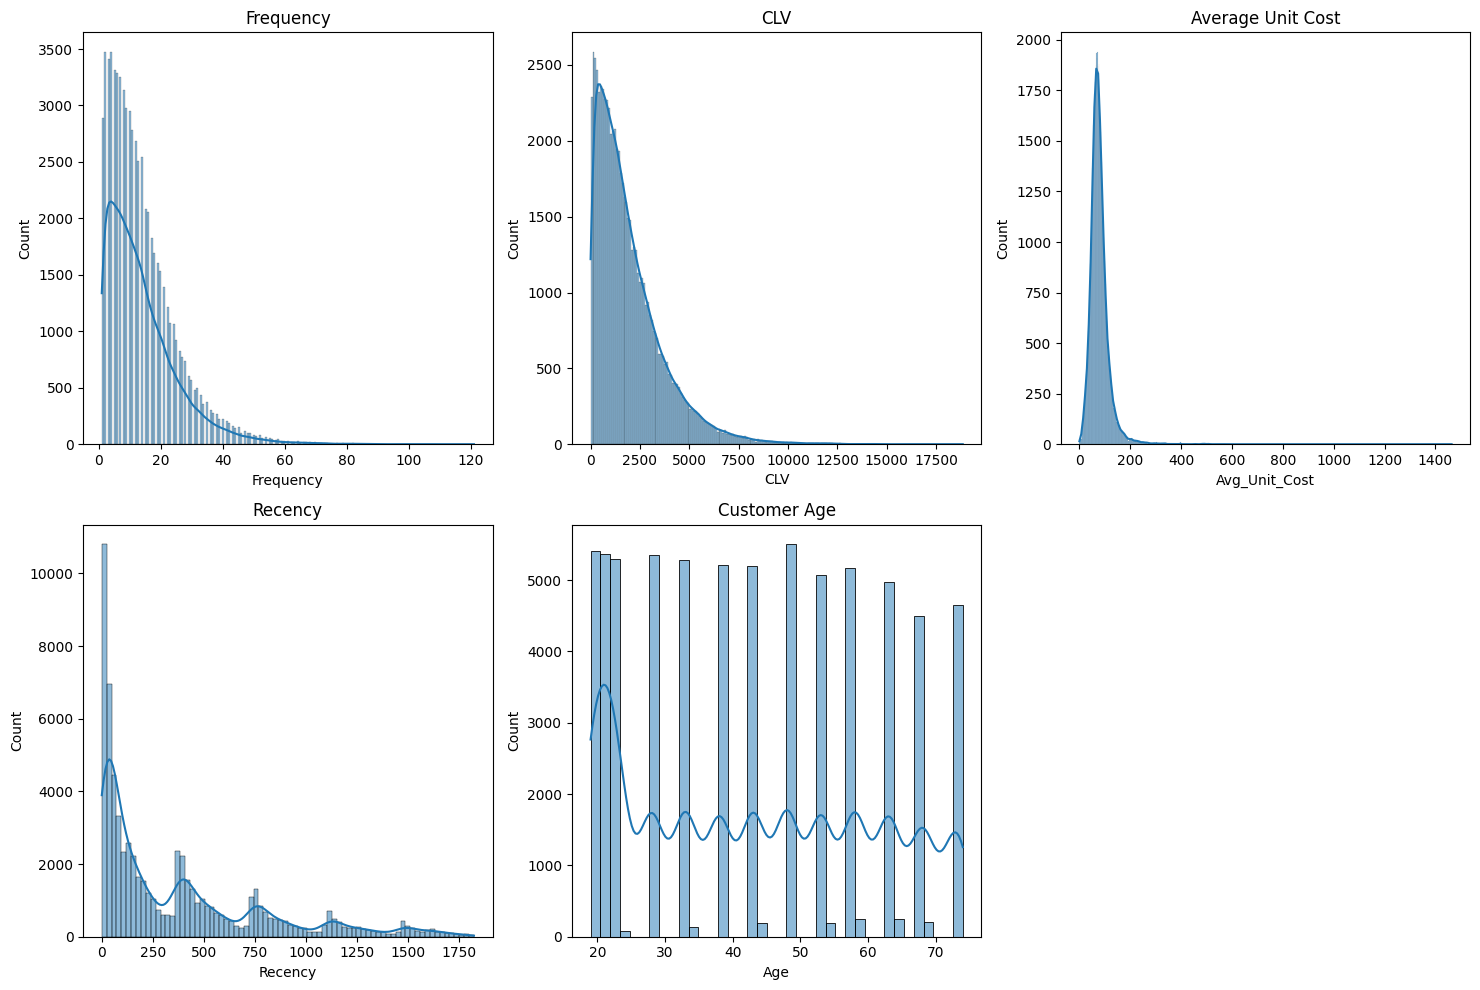

In [ ]:
# Visualise distribution of each feature using histograms with KDE curve
# Right-skewed distributions indicate majority of customers have low values
# while a small number have very high values
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.histplot(data=df_aggr['Frequency'], kde=True)
plt.title('Frequency')

plt.subplot(2, 3, 2)
sns.histplot(data=df_aggr['CLV'], kde=True)
plt.title('CLV')

plt.subplot(2, 3, 3)
sns.histplot(data=df_aggr['Avg_Unit_Cost'], kde=True)
plt.title('Average Unit Cost')

plt.subplot(2, 3, 4)
sns.histplot(data=df_aggr['Recency'], kde=True)
plt.title('Recency')

plt.subplot(2, 3, 5)
sns.histplot(data=df_aggr['Age'], kde=True)
plt.title('Customer Age')

plt.tight_layout()
plt.show()

The histograms reveal distinct distribution patterns across the five engineered features. Frequency, CLV, and Average Unit Cost are all heavily right-skewed, indicating that the majority of customers make infrequent purchases, generate modest revenue, and buy lower-cost items, while a small number of high-value customers drive disproportionately high values in these features. Recency is also right-skewed with notable secondary peaks, suggesting that while most customers have purchased recently, a long tail of inactive customers exists who have not engaged with the business for extended periods. Customer Age displays a roughly uniform distribution across the range of approximately 20 to 75 years, indicating a relatively even spread of customer ages with no dominant age group.


## 4.3 Boxplots

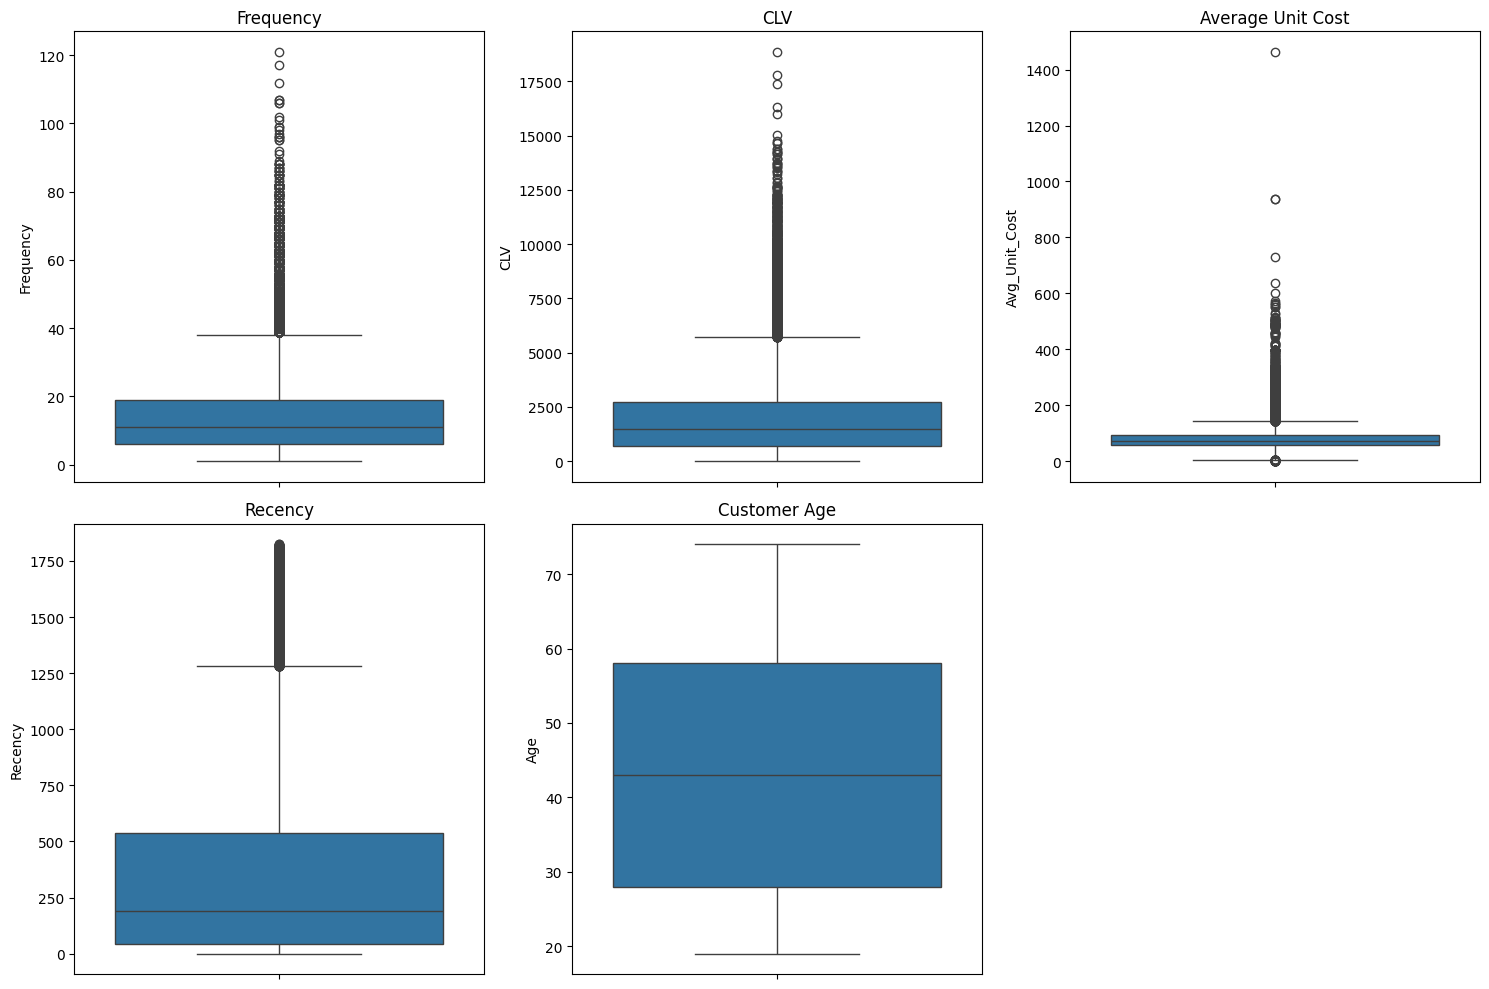

In [ ]:
# Boxplots to identify outliers in each feature
# Dots beyond the whiskers represent potential outliers
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.boxplot(data=df_aggr['Frequency'])
plt.title('Frequency')

plt.subplot(2, 3, 2)
sns.boxplot(data=df_aggr['CLV'])
plt.title('CLV')

plt.subplot(2, 3, 3)
sns.boxplot(data=df_aggr['Avg_Unit_Cost'])
plt.title('Average Unit Cost')

plt.subplot(2, 3, 4)
sns.boxplot(data=df_aggr['Recency'])
plt.title('Recency')

plt.subplot(2, 3, 5)
sns.boxplot(data=df_aggr['Age'])
plt.title('Customer Age')

plt.tight_layout()
plt.show()

The boxplots reveal the presence of outliers across the majority of features. Frequency, CLV, Average Unit Cost, and Recency all display a significant number of data points beyond the upper whisker, indicating customers with unusually high purchase frequency, lifetime value, unit cost preferences, and days since last purchase respectively. Customer Age shows no significant outliers, consistent with the uniform distribution observed in the histograms. As these outliers represent genuine customer behaviour rather than data entry errors, for example, high-CLV customers are the business's most valuable clients. So, they have been retained in the dataset. Removing them would distort the customer segmentation and result in a misleading picture of the customer base.

---
# 5. Finding the Optimal 'k'

## 5.0 Data Sampling

In [ ]:
small_df = scaled_data.sample(n=30000, random_state=42).reset_index(drop=True)

Due to the computational demands of iterative clustering algorithms on large datasets, the scaled data was reduced to a random sample of 30,000 customers. This sample is representative of the full dataset of 68,300 customers and is used for the Elbow method, Silhouette score, and Hierarchical clustering to determine the optimal number of clusters. The final K-means model will be applied to the full scaled dataset.

## 5.1 Elbow Method

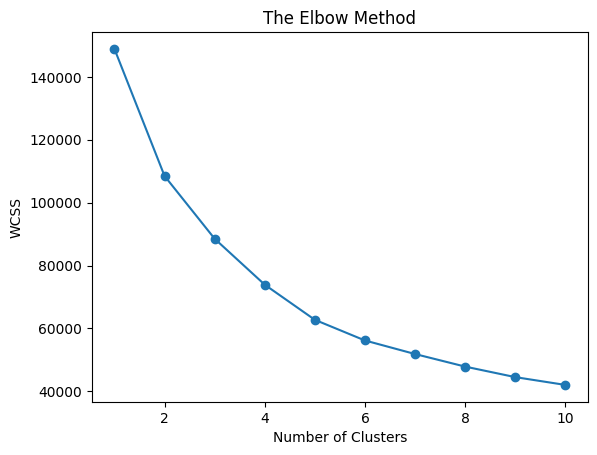

In [ ]:
# Elbow method: run K-means for k=1 to 10, store WCSS (inertia) for each k
# Look for the point where WCSS stops dropping sharply (the elbow)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=0, n_init=10)
    kmeans.fit(small_df)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

The Elbow Method plots the Within Cluster Sum of Squares (WCSS) against the number of clusters. As k increases, WCSS decreases as data points are closer to their centroids. The optimal k is identified at the point where the rate of decrease flattens — the "elbow". Based on the plot, the curve begins to flatten around k=5, suggesting this as a candidate for the optimal number of clusters. However, as the elbow is not sharply defined, the Silhouette score and Hierarchical clustering methods will be applied to further validate this choice.



## 5.2 Silhouette Score

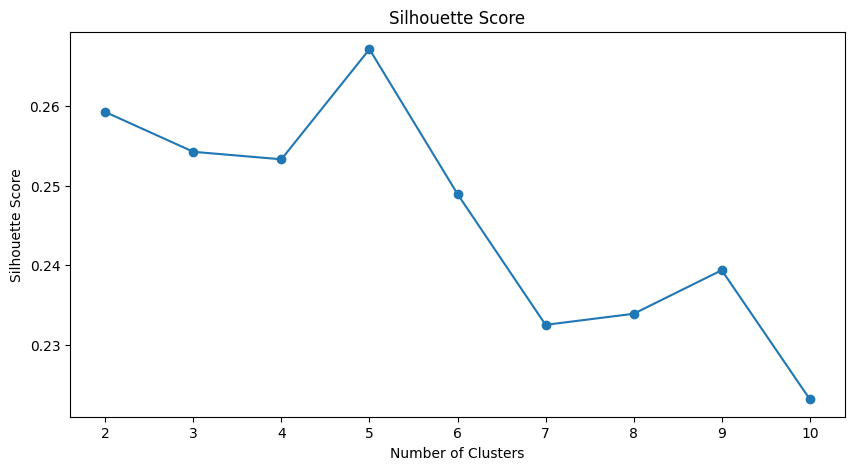

In [ ]:
# Silhouette score: measures how well each point fits its cluster
# Range: -1 to 1. Higher = better defined clusters. Pick k with highest score.
silhouette_scores = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=0, n_init=10)
    labels = kmeans.fit_predict(small_df)
    score = silhouette_score(small_df, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

The Silhouette score was calculated for k=2 through k=10. The highest average Silhouette score of approximately 0.27 was observed at k=5, indicating the most well-defined and separated cluster structure at this value. The second highest score of approximately 0.26 occurred at k=2; however, two clusters would be too broad to generate meaningful customer segments for marketing purposes. The Silhouette score therefore corroborates the finding from the Elbow method, with k=5 emerging as the optimal number of clusters. Hierarchical clustering will be performed next to further validate this choice.

## 5.3 Hierarchical Clustering

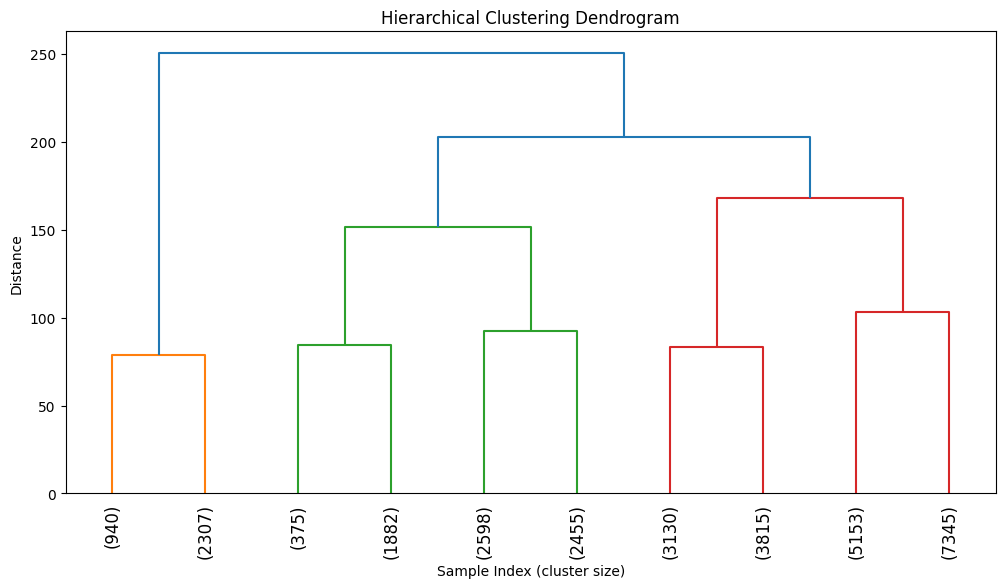

In [ ]:
# Hierarchical clustering using Ward linkage on sampled data
# Ward minimises within-cluster variance at each merge
Z = linkage(small_df, method='ward')

# Plot dendrogram — truncated to last 10 merges for readability
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=10, leaf_rotation=90, leaf_font_size=12)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index (cluster size)')
plt.ylabel('Distance')
plt.show()

The dendrogram visualises the hierarchical merging of clusters based on Ward linkage, which minimises within-cluster variance at each merge. The y-axis represents the distance between clusters at the point of merging — the larger the distance, the more dissimilar the clusters being combined. By drawing a horizontal line at a distance of approximately 100-150, five vertical lines are intersected, suggesting k=5 as the optimal number of clusters. This is consistent with both the Elbow method and the Silhouette score, providing strong convergent evidence that 5 clusters best represents the natural grouping structure within this customer dataset.

## 5.4 Optimal k Decision

Based on the convergent evidence from three independent methods, k=5 was selected as the optimal number of clusters. The Elbow method identified a notable flattening of the WCSS curve at k=5, the Silhouette score reached its highest value of approximately 0.267 at k=5 indicating well-separated clusters, and the Hierarchical clustering dendrogram supported 5 clusters when cut at a distance of approximately 100–150. The agreement across all three methods provides strong justification for proceeding with k=5 for the K-means clustering model.

---
# 6. K-means Clustering

In [ ]:
# Apply K-means with optimal k=5 on FULL scaled dataset
# k=5 determined by convergent evidence from Elbow, Silhouette, and Hierarchical methods
k = 5

kmeans = KMeans(n_clusters=k, init='k-means++', random_state=0, n_init=10)
df_aggr['Cluster'] = kmeans.fit_predict(scaled_data)

df_aggr['Cluster'].value_counts().sort_index()

,count
Cluster,
0,20189
1,22553
2,10596
3,11229
4,3733


K-means clustering was applied to the full scaled dataset of 68,300 customers using k=5, as determined by the Elbow method, Silhouette score, and Hierarchical clustering. The resulting cluster sizes are: Cluster 0 (20,189), Cluster 1 (22,553), Cluster 2 (10,596), Cluster 3 (11,229), and Cluster 4 (3,733).
- Clusters 0 and 1 are the largest and most similar in size, suggesting they capture the majority of typical customers.
- Clusters 2 and 3 are moderately sized and likely represent distinct customer sub-groups.
- Cluster 4 is notably smaller, containing only 3,733 customers, which may indicate a niche segment such as very high-value or highly inactive customers.

The boxplots in the following section will provide further insight into the characteristics of each cluster.

## 6.1 Customer Segments

In [ ]:
# Display cluster assignment for each customer
# Each customer ID is assigned to one of 5 clusters (0-4)
df_aggr[['Customer ID', 'Cluster']]

,Customer ID,Cluster
0,1,3
1,3,1
2,4,2
3,5,1
4,6,0
...,...,...
68295,94248,2
68296,94250,2
68297,94252,3
68298,94253,0


The table above displays the cluster assignment for each of the 68,300 unique customers, identified by their Customer ID. Each customer has been assigned to one of five clusters (0–4) by the K-means algorithm, enabling targeted marketing strategies to be developed for each distinct customer segment.

## 6.2 Cluster Boxplots

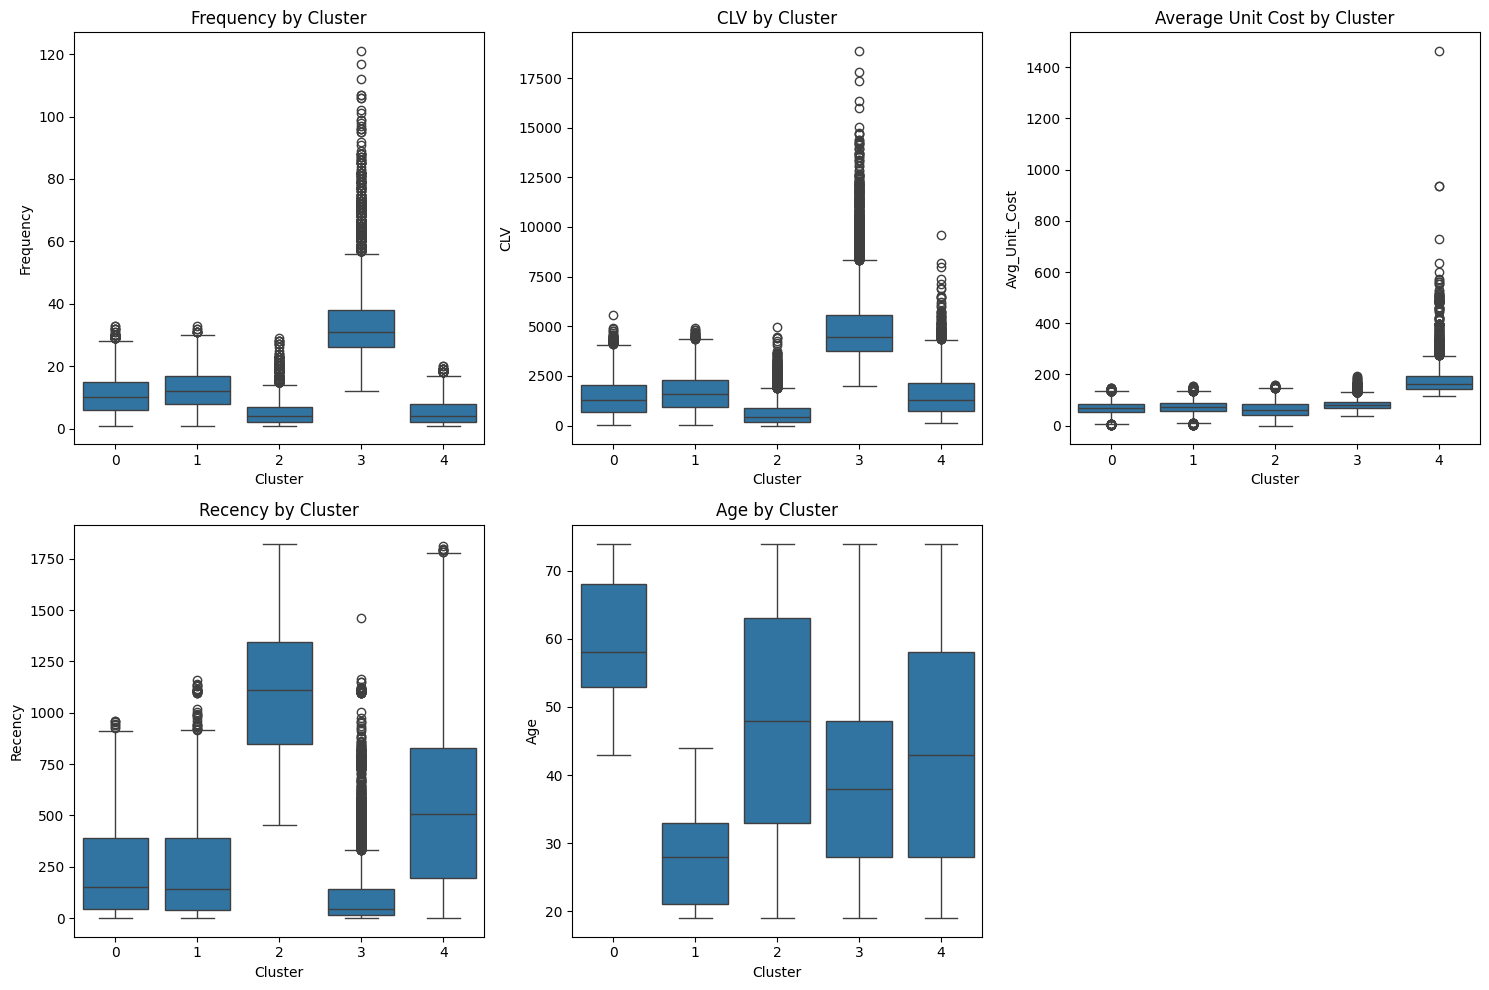

In [ ]:
# Boxplots split by cluster to reveal characteristics of each segment
# x=Cluster allows comparison of feature distributions across all 5 clusters
plt.figure(figsize = (15,10))

plt.subplot(2,3,1)
sns.boxplot (x='Cluster', y = 'Frequency', data = df_aggr)
plt.title('Frequency by Cluster')

plt.subplot(2,3,2)
sns.boxplot(x='Cluster', y='CLV', data = df_aggr)
plt.title('CLV by Cluster')

plt.subplot(2,3,3)
sns.boxplot(x = 'Cluster', y='Avg_Unit_Cost', data = df_aggr)
plt.title('Average Unit Cost by Cluster')

plt.subplot(2,3,4)
sns.boxplot(x = 'Cluster', y='Recency', data = df_aggr)
plt.title('Recency by Cluster')

plt.subplot(2,3,5)
sns.boxplot(x = 'Cluster', y='Age', data = df_aggr)
plt.title('Age by Cluster')

plt.tight_layout()
plt.show()

The cluster boxplots reveal distinct customer profiles across the five features, enabling meaningful business segmentation.
- Cluster 0 — Older Budget Buyers: This cluster displays low Recency (indicating recent purchase activity), moderate Frequency, and low CLV, suggesting customers who purchase regularly but spend modestly. The Age median is notably high (~57 years) compared to other clusters, identifying this group as older, budget-conscious shoppers.
- Cluster 1 — Younger Budget Buyers: Similar to Cluster 0, this group shows low Recency and low spending levels. However, the Age median is significantly less (~28 years), distinguishing them as a young demographic with similar purchasing behaviour to Cluster 0.
- Cluster 2 — Churned/Inactive Customers: Cluster 2 has the highest Recency median (~1,100 days), indicating these customers have not purchased in approximately 3 years. Combined with low Frequency and low CLV, these customers appear to have disengaged from the business and represent a churn risk requiring targeted win-back campaigns.
- Cluster 3 — High-Value Loyal Customers: This cluster stands out with the highest Frequency and highest CLV medians across all clusters, identifying them as the business's most valuable customers. Their low Recency confirms they remain actively engaged. Despite numerous outliers, the core segment represents loyal, high-spending customers who should be prioritised for retention programmes.
- Cluster 4 — Premium Occasional Buyers: Cluster 4 shows the highest Average Unit Cost median, indicating a preference for high-cost items. However, low Frequency and low Recency suggest these customers purchase less and have not engaged recently. This group represents premium shoppers who may respond well to exclusive or luxury product promotions.

---
# 7. Dimensionality Reduction

## 7.1 PCA

Variance explained: 65.3%


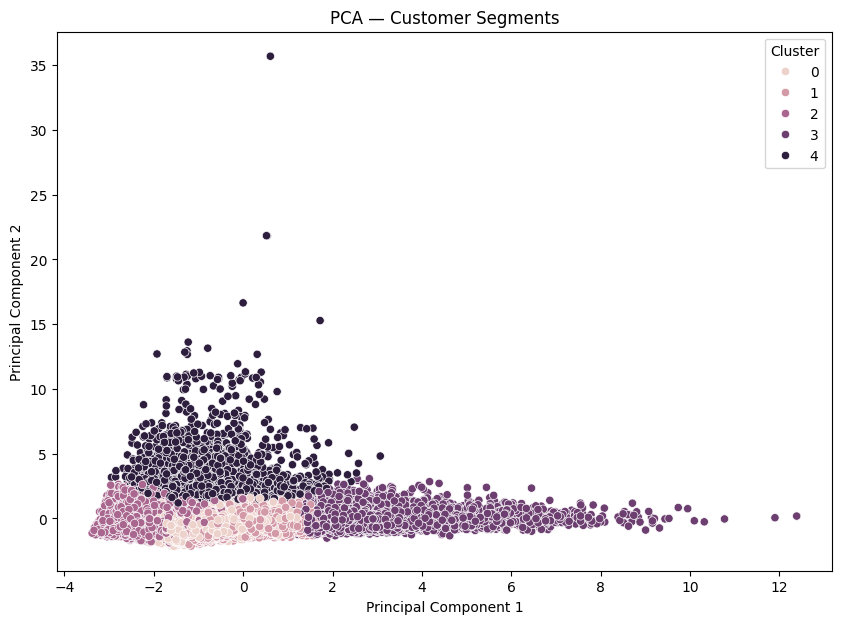

In [ ]:
# Reduce 5 features to 2 principal components for visualisation
# PCA is linear — preserves global structure
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=pca_components[:, 0],
    y=pca_components[:, 1],
    hue=df_aggr['Cluster']
)

plt.title('PCA — Customer Segments')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

Principal Component Analysis (PCA) was applied to the scaled dataset to reduce the five features to two dimensions for visualisation purposes. The two principal components together explain 65.3% of the total variance in the data, meaning 34.7% of information is lost in the compression.

The x-axis represents Principal Component 1 and the y-axis represents Principal Component 2 — both are abstract mathematical combinations of the original five features.

The scatter plot shows partial cluster separation, with some overlap between clusters. This overlap is expected — K-means performed hard clustering in the original 5-dimensional space, but compressing to 2D inevitably loses some of the information that was separating the clusters. The overlap therefore reflects the limitations of 2D visualisation rather than poor clustering quality.

Cluster 4 (Premium Occasional Buyers) is visibly separated above the main mass of customers on the y-axis, consistent with their distinctively high Average Unit Cost identified in the boxplots. Clusters 0 and 1 spread along the x-axis, reflecting their higher Recency values.

Overall, PCA provides a reasonable but imperfect visualisation of the customer segments due to the variance loss inherent in dimensionality reduction.

## 7.2 t-SNE

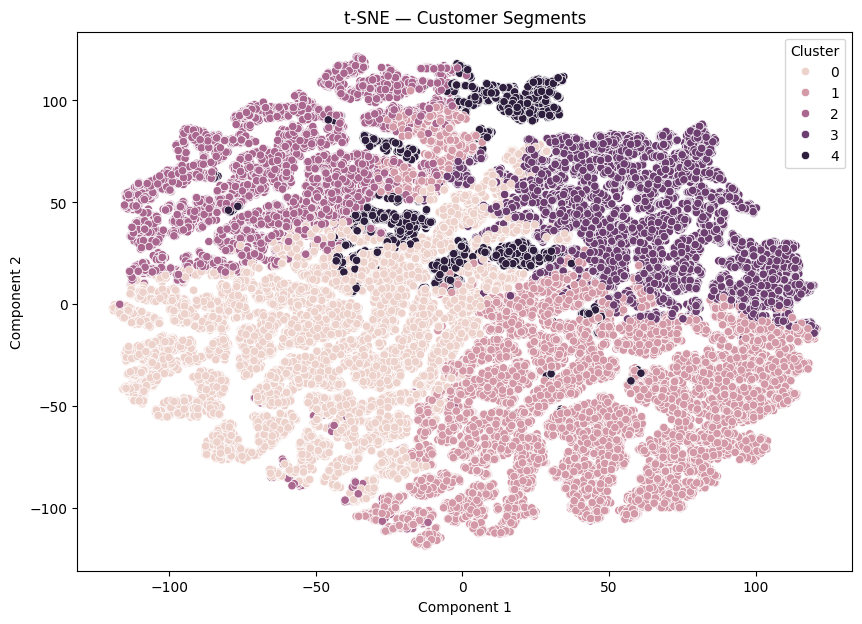

In [ ]:
# t-SNE: non-linear dimensionality reduction for visualisation
# Better than PCA at revealing local cluster structure but slower
# perplexity=30 balances local and global structure
tsne = TSNE(n_components=2, perplexity = 30, random_state=42)
tsne_components = tsne.fit_transform(scaled_data)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_components[:, 0],
    y=tsne_components[:, 1],
    hue=df_aggr['Cluster']
)

plt.title('t-SNE — Customer Segments')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

t-SNE was applied to the same scaled dataset to provide an alternative 2D visualisation of the customer segments. Unlike PCA, which is a linear technique, t-SNE is non-linear and preserves local neighbourhood structure, making it better suited for revealing distinct cluster boundaries in complex datasets.


The t-SNE plot demonstrates noticeably clearer cluster separation compared to PCA. Cluster 0 (Older Budget Buyers) dominates the bottom-left region, Cluster 1 (Younger Budget Buyers) spreads across the right side, Cluster 2 (Churned/Inactive Customers) is visible in the upper areas, Cluster 3 (High-Value Loyal Customers) is concentrated in distinct regions, and Cluster 4 (Premium Occasional Buyers) appears as small but visible groupings scattered around the top of the plot.


However, t-SNE has significant limitations — it took approximately 26 minutes to run on the full dataset of 68,300 customers, compared to 1-2 minutes for PCA. Additionally, unlike PCA, t-SNE does not provide a variance explained metric, making it harder to quantify how much information is retained. The axes have no interpretable meaning.


Overall, t-SNE provided superior visualisation for understanding cluster structure, while PCA offered a faster and more quantifiable approach. For large-scale or real-time applications, PCA would be the more practical choice despite its lower visual clarity.

# Reflect

In this project, I performed customer segmentation on a real-world e-commerce dataset containing 951,669 transactions. The analysis involved data preprocessing, feature engineering to create five customer-level metrics (Frequency, Recency, CLV, Average Unit Cost, and Age), and applying K-means clustering with k=5, determined through the Elbow method, Silhouette score, and Hierarchical clustering. The most important decision was selecting k=5, supported by convergent evidence from all three methods. The analysis revealed five distinct customer segments: Older Budget Buyers, Younger Budget Buyers, Churned/Inactive Customers, High-Value Loyal Customers, and Premium Occasional Buyers. PCA and t-SNE were applied to visualise the segments in 2D, with t-SNE providing clearer cluster separation. A key limitation is that the analysis is based on historical data up to 2016, and customer behaviour may have changed significantly since then. Additionally, only five features were used for segmentation, and incorporating additional variables such as geographic location or product category could further refine the customer profiles.

### Reference:
SAS, 2024. CUSTOMERS_CLEAN [Data set]. SAS. Last revised on 15 December 2021. [Accessed 20 February 2024].